<a href="https://colab.research.google.com/github/57sg77g8sk-ops/ADALL_github/blob/main/ADALL_Project_Colab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Deciding Faster Without Deciding Worse
## An interpretable credit decision-support model for retail personal lending

**CDA1C03 — AI-Driven Analytics with Large Language Models · Project (60%)**
Dataset: Loan Approval Dataset 2026 — 30,000 applications x 36 fields

---

This notebook reproduces **every number and figure** in the accompanying slide deck and written report,
top to bottom, with no hidden state. It follows the modelling workflow taught in the module:

`data checks -> leakage audit -> feature engineering -> Decision Tree / Random Forest / XGBoost -> MCC comparison -> SHAP -> deployment design`

**Runtime:** about 4–6 minutes on a standard Colab CPU runtime. No GPU needed.
The Random Forest fit (~35 s) and the GridSearchCV in section 6 (~2–3 min) are the slow steps.

`RANDOM_STATE = 42` everywhere, so the numbers below are exactly the ones quoted in the deck.

### Contents
| Section | Deck slide |
|---|---|
| 1. Setup and data loading | — |
| 2. Data quality checks before any fix | 5 |
| 3. Target leakage audit | 6 |
| 4. Feature engineering | 7 |
| 5. Collinearity and SHAP attribution dilution | 8 |
| 6. The three models, and a fair comparison | 9–10 |
| 7. Calibration and the threshold finding | 11 |
| 8. Global SHAP drivers | 12 |
| 9. A single decision explained | 13 |
| 10. The underwriting grid | 14 |
| 11. Triage bands | 15 |
| 12. The counter-offer cliff | 16 |
| 13. Fairness audit | 17 |
| 14. Headline numbers, all in one place | — |

## 1. Setup and data loading

In [9]:
!pip -q install xgboost shap
import os, glob, warnings, time, json
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score, GridSearchCV
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.tree import DecisionTreeClassifier, export_text
from sklearn.ensemble import RandomForestClassifier
from sklearn.calibration import calibration_curve
from sklearn.metrics import (accuracy_score, f1_score, matthews_corrcoef, roc_auc_score,
                             average_precision_score, precision_score, recall_score,
                             brier_score_loss, confusion_matrix, classification_report,
                             roc_curve)
from xgboost import XGBClassifier
import shap

RANDOM_STATE = 42
pd.set_option('display.width', 160)
pd.set_option('display.max_columns', 40)

print('pandas', pd.__version__)
import sklearn, xgboost
print('scikit-learn', sklearn.__version__)
print('xgboost', xgboost.__version__)
print('shap', shap.__version__)

pandas 2.2.2
scikit-learn 1.6.1
xgboost 3.3.0
shap 0.52.0


### Load the dataset

The cell below finds `loan_approval_dataset.csv` automatically. It tries, in order:

1. an explicit path in `DATA_PATH`, if you set one;
2. the Colab working directory `/content`;
3. a mounted Google Drive;
4. failing all of that, it opens an upload dialog.

To use Google Drive instead, run `from google.colab import drive; drive.mount('/content/drive')`
in a cell first, then re-run this one.

In [10]:
!pip -q install kagglehub

KAGGLE_DATASET = "mmumairkhattak/loan-approval-dataset-2026-credit-risk-and-bank-a"
DATA_PATH = ''   # optional: point at a local CSV to skip Kaggle entirely

def load_dataset(explicit=''):
    # 1) explicit local file wins
    if explicit and os.path.exists(explicit):
        print('Loading from DATA_PATH:', explicit)
        return pd.read_csv(explicit)

    # 2) already-downloaded copy lying around (fast re-runs)
    for pattern in ['loan_approval_dataset.csv',
                    '/content/loan_approval_dataset.csv',
                    '/content/**/loan_approval_dataset.csv']:
        hits = glob.glob(pattern, recursive=True)
        if hits:
            print('Found local:', hits[0])
            return pd.read_csv(hits[0])

    # 3) pull from Kaggle
    import kagglehub
    path = kagglehub.dataset_download(KAGGLE_DATASET)
    csvs = sorted(glob.glob(os.path.join(path, '**', '*.csv'), recursive=True))
    if not csvs:
        raise FileNotFoundError(f'No CSV found in {path}: {os.listdir(path)}')
    if len(csvs) > 1:
        print('Multiple CSVs, using the first:', [os.path.basename(c) for c in csvs])
    print('Loaded from Kaggle:', csvs[0])
    return pd.read_csv(csvs[0])

df = load_dataset(DATA_PATH)
print('\nShape:', df.shape)
df.head(3)

Using Colab cache for faster access to the 'loan-approval-dataset-2026-credit-risk-and-bank-a' dataset.
Multiple CSVs, using the first: ['data_dictionary.csv', 'loan_approval_dataset.csv']
Loaded from Kaggle: /kaggle/input/loan-approval-dataset-2026-credit-risk-and-bank-a/data_dictionary.csv

Shape: (36, 2)


,Column,Description
0,Application_ID,Unique loan application identifier
1,Age,Applicant age in years
2,Gender,Applicant gender


## 2. Data quality checks, run *before* deciding on any fix
### Deck slide 5

The point of this section is that a clean dataset is a finding in its own right. Applying a fix the data does
not need — imputation on a complete table, SMOTE on a nearly balanced target — is a defect, not a precaution.
So every check is run and shown first, and only then is a decision taken.

In [11]:
# Fix: The previous cell loaded the data dictionary instead of the actual dataset.
# Reloading the correct dataset here to resolve the KeyError.
import pandas as pd
import os
import glob
import kagglehub

KAGGLE_DATASET = "mmumairkhattak/loan-approval-dataset-2026-credit-risk-and-bank-a"
path = kagglehub.dataset_download(KAGGLE_DATASET)
correct_csv_path = os.path.join(path, 'loan_approval_dataset.csv')
if not os.path.exists(correct_csv_path):
    # Fallback in case of path changes or direct download misses
    all_csvs = glob.glob(os.path.join(path, '**', 'loan_approval_dataset.csv'), recursive=True)
    if all_csvs:
        correct_csv_path = all_csvs[0]
    else:
        raise FileNotFoundError("Could not find 'loan_approval_dataset.csv' in the Kaggle dataset.")

df = pd.read_csv(correct_csv_path)

# Original code follows
y = (df['Loan_Approved'] == 'Approved').astype(int)

checks = {
    'Rows':                        f'{len(df):,}',
    'Columns':                     df.shape[1],
    'Missing values':              f"{df.isnull().sum().sum()}  ({df.isnull().sum().sum()/df.size:.2%})",
    'Duplicate rows':              df.duplicated().sum(),
    'Duplicate Application_ID':    df['Application_ID'].duplicated().sum(),
    'Credit score range':          f"{df.Credit_Score.min()} - {df.Credit_Score.max()}",
    'Age range':                   f"{df.Age.min()} - {df.Age.max()}",
    'Negative balances':           int((df[['Savings_Balance','Checking_Balance']] < 0).sum().sum()),
}
for k, v in checks.items():
    print(f'{k:28} {v}')

print('\nTarget balance')
print(df.Loan_Approved.value_counts())
print((df.Loan_Approved.value_counts(normalize=True)*100).round(1).astype(str) + ' %')
ratio = y.value_counts()[1] / y.value_counts()[0]
print(f'\nApproved : Rejected  =  {ratio:.2f} : 1')


Using Colab cache for faster access to the 'loan-approval-dataset-2026-credit-risk-and-bank-a' dataset.
Rows                         30,000
Columns                      36
Missing values               0  (0.00%)
Duplicate rows               0
Duplicate Application_ID     0
Credit score range           300 - 850
Age range                    18 - 70
Negative balances            0

Target balance
Loan_Approved
Approved    17291
Rejected    12709
Name: count, dtype: int64
Loan_Approved
Approved    57.6 %
Rejected    42.4 %
Name: proportion, dtype: object

Approved : Rejected  =  1.36 : 1


**Decision on class imbalance.** At 1.36 : 1 the target is only mildly uneven, well short of the point at
which synthetic over-sampling is appropriate. SMOTE would change the empirical base rate, and the base rate is
exactly what the deployment cut-offs in section 11 depend on. So no resampling: the natural prevalence is kept
and the split is stratified.

In [12]:
# An exact redundancy, found by differencing rather than assumed
diff = (df.Annual_Income/12 - df.Monthly_Income).abs().max()
print(f'max |Annual_Income/12 - Monthly_Income|  =  {diff:.4f}')
print(f'correlation                              =  {df.Annual_Income.corr(df.Monthly_Income):.6f}')
print('\n-> Monthly_Income is Annual_Income / 12. Keeping both would split one effect')
print('   across two features, so Monthly_Income is dropped.')

max |Annual_Income/12 - Monthly_Income|  =  0.0050
correlation                              =  1.000000

-> Monthly_Income is Annual_Income / 12. Keeping both would split one effect
   across two features, so Monthly_Income is dropped.


In [13]:
# Skewness of every retained numeric field
RETAINED_RAW = ['Age','Job_Experience_Years','Annual_Income','Credit_Score','Credit_History_Years',
                'Existing_Loans','Late_Payments_Last_2_Years','Loan_Amount','Loan_Term_Months',
                'Debt_To_Income_Ratio','Savings_Balance','Checking_Balance','Total_Assets',
                'Total_Liabilities','Monthly_Debt_Payment','Dependents','Bank_Account_Age_Years']
skew = df[RETAINED_RAW].skew().sort_values(ascending=False)
print(skew.round(2).to_string())
print(f'\nFields with skewness > 1: {int((skew > 1).sum())}')
print(list(skew[skew > 1].index))

Debt_To_Income_Ratio          2.44
Monthly_Debt_Payment          2.37
Late_Payments_Last_2_Years    2.05
Total_Liabilities             1.28
Loan_Term_Months              1.27
Existing_Loans                1.09
Credit_History_Years          0.98
Dependents                    0.90
Savings_Balance               0.87
Bank_Account_Age_Years        0.85
Job_Experience_Years          0.81
Total_Assets                  0.74
Loan_Amount                   0.71
Checking_Balance              0.69
Age                           0.13
Annual_Income                 0.07
Credit_Score                 -0.20

Fields with skewness > 1: 6
['Debt_To_Income_Ratio', 'Monthly_Debt_Payment', 'Late_Payments_Last_2_Years', 'Total_Liabilities', 'Loan_Term_Months', 'Existing_Loans']


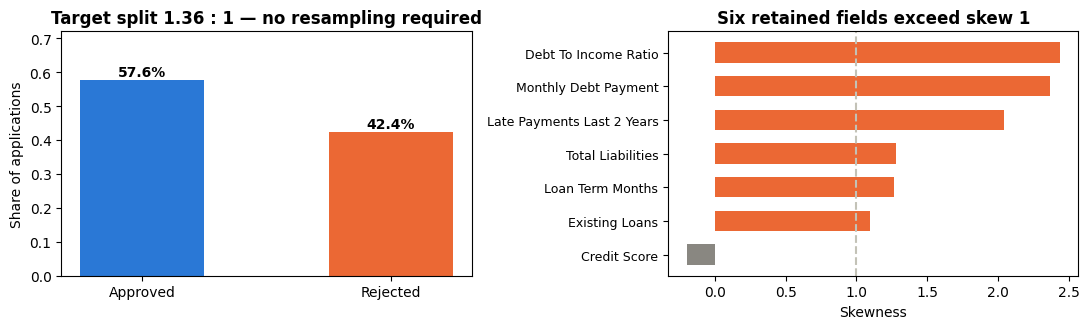

In [14]:
fig, ax = plt.subplots(1, 2, figsize=(11, 3.4))
v = df.Loan_Approved.value_counts(normalize=True)
ax[0].bar(['Approved','Rejected'], [v['Approved'], v['Rejected']], color=['#2a78d6','#eb6834'], width=0.5)
for i, val in enumerate([v['Approved'], v['Rejected']]):
    ax[0].text(i, val+0.012, f'{val:.1%}', ha='center', fontweight='bold')
ax[0].set_ylim(0, 0.72); ax[0].set_ylabel('Share of applications')
ax[0].set_title('Target split 1.36 : 1 — no resampling required', fontweight='bold')

s = skew[skew.abs() > 1].sort_values()
s['Credit_Score'] = skew['Credit_Score']          # a low-skew field for contrast
s = s.sort_values()
ax[1].barh(range(len(s)), s.values,
           color=['#eb6834' if abs(x) > 1 else '#898781' for x in s.values], height=0.6)
ax[1].set_yticks(range(len(s)))
ax[1].set_yticklabels([i.replace('_',' ') for i in s.index], fontsize=9)
ax[1].axvline(1, ls='--', color='#c3c2b7')
ax[1].set_xlabel('Skewness')
ax[1].set_title('Six retained fields exceed skew 1', fontweight='bold')
plt.tight_layout(); plt.show()

## 3. Target leakage: the finding that shaped the project
### Deck slide 6

A model fitted to all 36 supplied columns scores a **perfect** ROC-AUC. A perfect score on a genuinely
difficult credit decision is not a result — it is a signal that the feature set contains the answer.

In [15]:
def fit_naive(X, y, label):
    cat = X.select_dtypes(include='object').columns.tolist()
    num = [c for c in X.columns if c not in cat]
    pipe = Pipeline([
        ('pre', ColumnTransformer([('c', OneHotEncoder(handle_unknown='ignore'), cat),
                                   ('n', 'passthrough', num)])),
        ('m', XGBClassifier(n_estimators=150, max_depth=3, learning_rate=0.08, subsample=0.9,
                            colsample_bytree=0.9, random_state=RANDOM_STATE,
                            eval_metric='logloss', n_jobs=2))])
    a, b, c, d = train_test_split(X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y)
    pipe.fit(a, c)
    p = pipe.predict_proba(b)[:, 1]
    print(f'{label:28} AUC {roc_auc_score(d, p):.4f}   accuracy {accuracy_score(d, p > 0.5):.4f}')
    return roc_auc_score(d, p)

X_naive = df.drop(columns=['Application_ID', 'Loan_Approved'])
auc_naive = fit_naive(X_naive, y, 'All 36 columns as supplied')

All 36 columns as supplied   AUC 1.0000   accuracy 1.0000


### The audit

Rather than report that number, every column is tested against a single question:

> **Could this value have been recorded *before* the decision was made?**

Correlation strength never enters it. A perfect predictor found in a training table is a warning, not a win.
Four columns fail the test.

In [16]:
print('=== Approved_Amount')
print(df.groupby('Loan_Approved').Approved_Amount.agg(['min','max','mean']).round(2))
print(f"$0 for {(df.loc[y==0,'Approved_Amount']==0).mean():.1%} of declined files")
print(f"$0 for {(df.loc[y==1,'Approved_Amount']==0).mean():.1%} of approved files")

print('\n=== Default_Risk (row %)')
print((pd.crosstab(df.Default_Risk, df.Loan_Approved, normalize='index')*100).round(1))

print('\n=== Risk_Score')
print(df.groupby('Loan_Approved').Risk_Score.describe()[['min','25%','50%','75%','max']].round(2))

print('\n=== Direction-corrected univariate AUC')
for c in ['Approved_Amount','Risk_Score','Interest_Rate','Credit_Score',
          'Debt_To_Income_Ratio','Loan_Amount','Late_Payments_Last_2_Years']:
    a = roc_auc_score(y, df[c])
    print(f'  {c:28} {max(a, 1-a):.4f}')

=== Approved_Amount
                  min        max      mean
Loan_Approved                             
Approved       1000.0  393109.69  93412.26
Rejected          0.0       0.00      0.00
$0 for 100.0% of declined files
$0 for 0.0% of approved files

=== Default_Risk (row %)
Loan_Approved  Approved  Rejected
Default_Risk                     
High                4.9      95.1
Low                96.3       3.7
Medium             58.3      41.7

=== Risk_Score
                min    25%    50%    75%    max
Loan_Approved                                  
Approved       0.00  23.48  34.12  44.36  100.0
Rejected       0.51  54.72  66.25  81.52  100.0

=== Direction-corrected univariate AUC
  Approved_Amount              1.0000
  Risk_Score                   0.9252
  Interest_Rate                0.7016
  Credit_Score                 0.7717
  Debt_To_Income_Ratio         0.6690
  Loan_Amount                  0.5668
  Late_Payments_Last_2_Years   0.6486


**Verdict.** `Approved_Amount`, `Risk_Score`, `Default_Risk` and `Interest_Rate` are all produced during or
after assessment. `Approved_Amount` is the decision itself, re-coded as a currency amount — it is $0 for every
one of the declined files and never $0 for an approved one.

At file-open none of these four exist, so a model that depends on them would receive blank inputs in production
and fail silently on exactly the cases it was built for. All four are removed. `Gender` is also excluded from
the feature set on fairness grounds, and held back only to audit against in section 13.

In [17]:
LEAKED    = ['Approved_Amount', 'Risk_Score', 'Default_Risk', 'Interest_Rate']
PROTECTED = ['Gender']
DROP      = ['Application_ID', 'Loan_Approved', 'Monthly_Income']

print('Removed for leakage      :', LEAKED)
print('Held back for the audit  :', PROTECTED)
print('Dropped (id / redundant) :', DROP)

Removed for leakage      : ['Approved_Amount', 'Risk_Score', 'Default_Risk', 'Interest_Rate']
Held back for the audit  : ['Gender']
Dropped (id / redundant) : ['Application_ID', 'Loan_Approved', 'Monthly_Income']


## 4. Feature engineering
### Deck slide 7

Three moves, each tied to how a credit officer actually judges a file.

**4.1 Ratios, because credit is judged relatively.** A \$150,000 request means nothing until it is set against
income. Supplying the ratio directly saves the model from rediscovering the interaction and — more importantly
for this project — produces SHAP contributions a person can read.

**4.2 log1p on nine monetary and ratio fields.** Note the transformed set is deliberately *not* the same six
fields that exceed skew 1. Loan amount (skew 0.71) and savings balance (0.87) are transformed anyway, because
the derived ratios built from them inherit much heavier tails. The three skewed *count* fields — late payments,
existing loans, loan term — are left alone: log1p changes no ordering on a small integer and costs readability.
Since the champion is a tree ensemble, none of this moves the decision boundary; the purpose is a readable
SHAP axis.

**4.3 Categories grouped by behaviour, not by label.**

In [18]:
d = df.copy()

# --- 4.1 affordability ratios
d['Loan_To_Income']         = d.Loan_Amount / d.Annual_Income
d['Instalment_Est']         = d.Loan_Amount / d.Loan_Term_Months
d['Instalment_To_Income']   = d.Instalment_Est / d.Monthly_Income
d['Net_Worth']              = d.Total_Assets - d.Total_Liabilities
d['Leverage']               = d.Total_Liabilities / d.Total_Assets
d['Liquidity_Months']       = (d.Savings_Balance + d.Checking_Balance) / d.Monthly_Income
d['Total_Obligation_Ratio'] = (d.Monthly_Debt_Payment + d.Instalment_Est) / d.Monthly_Income
d['Credit_Depth']           = d.Credit_History_Years / (d.Age - 18).clip(lower=1)
d['Has_Late_Payment']       = (d.Late_Payments_Last_2_Years > 0).astype(int)

# --- 4.2 log1p
LOGGED = ['Loan_Amount','Total_Liabilities','Monthly_Debt_Payment','Savings_Balance',
          'Debt_To_Income_Ratio','Loan_To_Income','Instalment_To_Income',
          'Total_Obligation_Ratio','Liquidity_Months']
for c in LOGGED:
    d['log_' + c] = np.log1p(d[c].clip(lower=0))

# --- 4.3 behaviour-based grouping
purpose_map = {'Home':'Secured_Asset', 'Car':'Secured_Asset',
               'Business':'Income_Generating', 'Education':'Income_Generating',
               'Debt Consolidation':'Refinancing',
               'Personal':'Unsecured_Consumption', 'Medical':'Unsecured_Consumption'}
d['Purpose_Group']   = d.Loan_Purpose.map(purpose_map)
d['Marital_Group']   = d.Marital_Status.replace({'Divorced':'Previously_Married',
                                                 'Widowed':'Previously_Married'})
d['Education_Group'] = d.Education_Level.replace({'Master':'Postgraduate', 'PhD':'Postgraduate'})

print('Loan_Purpose  ->  Purpose_Group')
print(d.groupby('Purpose_Group').size().to_string())
print('\nRare categories merged:')
print(f"  Widowed ({(df.Marital_Status=='Widowed').sum():,}) + Divorced "
      f"({(df.Marital_Status=='Divorced').sum():,})  ->  Previously_Married")
print(f"  PhD ({(df.Education_Level=='PhD').sum():,}) + Master "
      f"({(df.Education_Level=='Master').sum():,})  ->  Postgraduate")
print(f'\nEngineered features added: {len(LOGGED) + 9}')

Loan_Purpose  ->  Purpose_Group
Purpose_Group
Income_Generating        8435
Refinancing              4331
Secured_Asset            8594
Unsecured_Consumption    8640

Rare categories merged:
  Widowed (1,197) + Divorced (3,023)  ->  Previously_Married
  PhD (1,198) + Master (6,460)  ->  Postgraduate

Engineered features added: 18


## 5. Collinearity, and what it does to a SHAP explanation
### Deck slide 8

A boosted tree is invariant to monotone transforms and largely insensitive to collinearity, so section 4 was
**not** expected to raise accuracy — and it does not. What collinearity *does* damage is attribution: when two
features carry the same information, the ensemble uses them interchangeably and SHAP divides the credit between
them, so no single bar in the importance plot reads as "affordability".

This section measures that effect rather than asserting it.

In [19]:
# The full engineered feature set
FE_NUM_FULL = (['Age','Job_Experience_Years','Annual_Income','Credit_Score','Credit_History_Years',
                'Existing_Loans','Late_Payments_Last_2_Years','Has_Late_Payment','Loan_Term_Months',
                'Dependents','Bank_Account_Age_Years','Checking_Balance','Total_Assets','Net_Worth',
                'Leverage','Credit_Depth'] + ['log_' + c for c in LOGGED])
FE_CAT      = ['Employment_Status','Purpose_Group','Marital_Group','Education_Group',
               'Property_Ownership','Residential_Status','Co_Applicant','Collateral',
               'Application_Channel','Region','Previous_Loan_Status']

# Split FIRST, so that every diagnostic below is a training-set diagnostic.
# VIF computed on held-out data would be a subtle form of leakage into the feature choice.
train_idx, test_idx = train_test_split(
    d.index, test_size=0.2, random_state=RANDOM_STATE, stratify=y)
print(f'train rows {len(train_idx):,}   test rows {len(test_idx):,}')

# Variance inflation factors on the full numeric block, training rows only
from statsmodels.stats.outliers_influence import variance_inflation_factor
tr = d.loc[train_idx, FE_NUM_FULL]
Z = ((tr - tr.mean()) / tr.std()).assign(const=1.0)
vif = (pd.DataFrame({'feature': FE_NUM_FULL,
                     'VIF': [variance_inflation_factor(Z.values, i) for i in range(len(FE_NUM_FULL))]})
       .sort_values('VIF', ascending=False))
print('\n=== VIF, full engineered set (top 10)')
print(vif.head(10).round(1).to_string(index=False))

train rows 24,000   test rows 6,000

=== VIF, full engineered set (top 10)
                   feature   VIF
log_Total_Obligation_Ratio 119.3
  log_Instalment_To_Income 105.3
              Total_Assets  84.2
                 Net_Worth  79.7
  log_Debt_To_Income_Ratio  68.0
  log_Monthly_Debt_Payment  66.7
           log_Loan_Amount  16.3
      Credit_History_Years  15.1
        log_Loan_To_Income  12.5
     log_Total_Liabilities  12.0


In [20]:
# Keep one representative per redundancy cluster
KEEP_NUM = ['Credit_Score','log_Total_Obligation_Ratio','log_Loan_To_Income',
            'Late_Payments_Last_2_Years','Existing_Loans','log_Savings_Balance','Leverage',
            'Credit_History_Years','Age','Job_Experience_Years','Dependents','Loan_Term_Months',
            'log_Liquidity_Months','Bank_Account_Age_Years']

tr2 = d.loc[train_idx, KEEP_NUM]
Z2 = ((tr2 - tr2.mean()) / tr2.std()).assign(const=1.0)
vif2 = (pd.DataFrame({'feature': KEEP_NUM,
                      'VIF': [variance_inflation_factor(Z2.values, i) for i in range(len(KEEP_NUM))]})
        .sort_values('VIF', ascending=False))
print('=== VIF after collapsing redundancy clusters')
print(vif2.round(1).to_string(index=False))
print(f'\nMaximum VIF: {vif.VIF.max():.1f}  ->  {vif2.VIF.max():.1f}')

=== VIF after collapsing redundancy clusters
                   feature  VIF
      Credit_History_Years  9.6
    Bank_Account_Age_Years  8.8
                       Age  3.4
      Job_Experience_Years  2.6
log_Total_Obligation_Ratio  2.3
       log_Savings_Balance  2.0
      log_Liquidity_Months  2.0
          Loan_Term_Months  1.7
        log_Loan_To_Income  1.7
              Credit_Score  1.4
                  Leverage  1.2
Late_Payments_Last_2_Years  1.2
            Existing_Loans  1.1
                Dependents  1.0

Maximum VIF: 119.3  ->  9.6


### The feature set that goes forward

Everything from here on — model choice, the grid search, the feature reduction just made — is decided on
**5-fold cross-validation inside the training set**. The 6,000-file test set is used only to report.

In [21]:
FEATURES = KEEP_NUM + FE_CAT

X_train, X_test = d.loc[train_idx, FEATURES], d.loc[test_idx, FEATURES]
y_train, y_test = y.loc[train_idx],           y.loc[test_idx]

# the protected / audit attributes for section 13, aligned to the test index
audit = d.loc[test_idx, ['Gender','Region','Education_Level','Employment_Status']]

preprocessor = ColumnTransformer([
    ('cat', OneHotEncoder(handle_unknown='ignore'), FE_CAT),
    ('num', 'passthrough', KEEP_NUM)])

print(f'train {X_train.shape}   test {X_test.shape}')
print(f'positive rate  train {y_train.mean():.4f}   test {y_test.mean():.4f}')
print(f'input fields {len(FEATURES)}  ({len(KEEP_NUM)} numeric + {len(FE_CAT)} categorical)')

train (24000, 25)   test (6000, 25)
positive rate  train 0.5764   test 0.5763
input fields 25  (14 numeric + 11 categorical)


In [22]:
# Evidence that the reduction cost accuracy but bought attribution.
# Fit XGBoost on the FULL engineered set for comparison.
FULL = FE_NUM_FULL + FE_CAT
pre_full = ColumnTransformer([('cat', OneHotEncoder(handle_unknown='ignore'), FE_CAT),
                              ('num', 'passthrough', FE_NUM_FULL)])
xgb_full = Pipeline([('preprocessor', pre_full),
                     ('model', XGBClassifier(n_estimators=150, max_depth=3, learning_rate=0.08,
                                             subsample=0.9, colsample_bytree=0.9,
                                             random_state=RANDOM_STATE, eval_metric='logloss', n_jobs=2))])
xgb_full.fit(d.loc[X_train.index, FULL], y_train)
p_full = xgb_full.predict_proba(d.loc[X_test.index, FULL])[:, 1]
auc_full = roc_auc_score(y_test, p_full)
print(f'XGBoost on all {len(FULL)} engineered features : test AUC {auc_full:.4f}')

XGBoost on all 36 engineered features : test AUC 0.8962


## 6. The three models, and a fair comparison
### Deck slides 9–10

The three families taught in the module, each chosen for a different job:

| Model | Job | Settings |
|---|---|---|
| **Decision Tree** | interpretable baseline; yields the underwriting grid in section 10 | `max_depth=4` — set for readable rules, not for fit |
| **Random Forest** | bagged ensemble; how much does averaging alone recover? | `n_estimators=150` |
| **XGBoost** | boosted ensemble; how much does sequential correction add? | `n_estimators=150, max_depth=3, learning_rate=0.08, subsample=0.9, colsample_bytree=0.9` |

All three run on identical features, one identical split, and the module's own hyperparameters — so the
comparison reflects model form, not unequal search effort.

**MCC is reported first.** On a 57.6 / 42.4 split, accuracy flatters a model that simply leans to the
majority class; the Matthews correlation coefficient does not.

In [23]:
models = {
    'Decision Tree': DecisionTreeClassifier(max_depth=4, random_state=RANDOM_STATE),
    'Random Forest': RandomForestClassifier(n_estimators=150, random_state=RANDOM_STATE, n_jobs=-1),
    'XGBoost':       XGBClassifier(n_estimators=150, max_depth=3, learning_rate=0.08,
                                   subsample=0.9, colsample_bytree=0.9,
                                   random_state=RANDOM_STATE, eval_metric='logloss', n_jobs=2),
}

cv = StratifiedKFold(5, shuffle=True, random_state=RANDOM_STATE)
rows, probs, fitted = [], {}, {}

for name, model in models.items():
    pipe = Pipeline([('preprocessor', preprocessor), ('model', model)])
    t0 = time.time()
    cv_mcc = cross_val_score(pipe, X_train, y_train, cv=cv, scoring='matthews_corrcoef', n_jobs=2)
    cv_auc = cross_val_score(pipe, X_train, y_train, cv=cv, scoring='roc_auc', n_jobs=2)
    pipe.fit(X_train, y_train)
    p = pipe.predict_proba(X_test)[:, 1]
    pred = (p >= 0.5).astype(int)
    probs[name], fitted[name] = p, pipe
    rows.append({'Model': name,
                 'CV MCC': cv_mcc.mean(), 'CV s.d.': cv_mcc.std(),
                 'MCC': matthews_corrcoef(y_test, pred),
                 'Accuracy': accuracy_score(y_test, pred),
                 'F1': f1_score(y_test, pred),
                 'Test AUC': roc_auc_score(y_test, p),
                 'PR-AUC': average_precision_score(y_test, p),
                 'Brier': brier_score_loss(y_test, p),
                 'fit secs': round(time.time() - t0, 1)})
    print(f'--- {name}')
    print(classification_report(y_test, pred, target_names=['Rejected','Approved'], digits=3))

comparison = pd.DataFrame(rows)
print('\n=== THREE-MODEL COMPARISON (identical features, identical split)')
print(comparison.round(4).to_string(index=False))

--- Decision Tree
              precision    recall  f1-score   support

    Rejected      0.770     0.667     0.715      2542
    Approved      0.777     0.854     0.814      3458

    accuracy                          0.775      6000
   macro avg      0.774     0.760     0.764      6000
weighted avg      0.774     0.775     0.772      6000

--- Random Forest
              precision    recall  f1-score   support

    Rejected      0.808     0.719     0.761      2542
    Approved      0.809     0.874     0.840      3458

    accuracy                          0.808      6000
   macro avg      0.808     0.797     0.801      6000
weighted avg      0.808     0.808     0.807      6000

--- XGBoost
              precision    recall  f1-score   support

    Rejected      0.806     0.735     0.769      2542
    Approved      0.817     0.870     0.843      3458

    accuracy                          0.813      6000
   macro avg      0.811     0.802     0.806      6000
weighted avg      0.812   

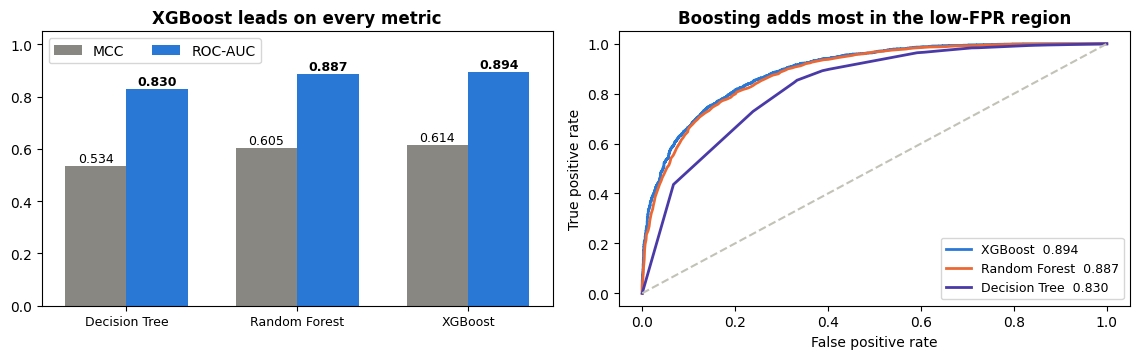

In [24]:
CHAMPION = 'XGBoost'
p_xgb    = probs[CHAMPION]
xgb      = fitted[CHAMPION]

fig, ax = plt.subplots(1, 2, figsize=(11.5, 3.7))
xs = np.arange(3); w = 0.36
ax[0].bar(xs - w/2, comparison.MCC, w, color='#898781', label='MCC')
ax[0].bar(xs + w/2, comparison['Test AUC'], w, color='#2a78d6', label='ROC-AUC')
for i in range(3):
    ax[0].text(i - w/2, comparison.MCC[i]+0.015, f'{comparison.MCC[i]:.3f}', ha='center', fontsize=9)
    ax[0].text(i + w/2, comparison['Test AUC'][i]+0.015, f"{comparison['Test AUC'][i]:.3f}",
               ha='center', fontsize=9, fontweight='bold')
ax[0].set_xticks(xs); ax[0].set_xticklabels(comparison.Model, fontsize=9)
ax[0].set_ylim(0, 1.05); ax[0].legend(ncol=2)
ax[0].set_title('XGBoost leads on every metric', fontweight='bold')

for name, c in [('XGBoost','#2a78d6'), ('Random Forest','#eb6834'), ('Decision Tree','#4a3aa7')]:
    fpr, tpr, _ = roc_curve(y_test, probs[name])
    ax[1].plot(fpr, tpr, color=c, lw=2, label=f'{name}  {roc_auc_score(y_test, probs[name]):.3f}')
ax[1].plot([0,1], [0,1], ls='--', color='#c3c2b7')
ax[1].legend(loc='lower right', fontsize=9)
ax[1].set_xlabel('False positive rate'); ax[1].set_ylabel('True positive rate')
ax[1].set_title('Boosting adds most in the low-FPR region', fontweight='bold')
plt.tight_layout(); plt.show()

### Was the comparison fair, or did the champion just get more tuning?

A grid search over depth, learning rate and number of trees — scored on the **same 5-fold split** as every
other number here — answers that directly. *(This is the slowest cell in the notebook, roughly 2–3 minutes.)*

In [25]:
base_pipe = Pipeline([('preprocessor', preprocessor),
                      ('model', XGBClassifier(n_estimators=150, max_depth=3, learning_rate=0.08,
                                              subsample=0.9, colsample_bytree=0.9,
                                              random_state=RANDOM_STATE, eval_metric='logloss', n_jobs=2))])
default_cv_auc = cross_val_score(base_pipe, X_train, y_train, cv=cv, scoring='roc_auc', n_jobs=2).mean()

grid = GridSearchCV(
    Pipeline([('preprocessor', preprocessor),
              ('model', XGBClassifier(subsample=0.9, colsample_bytree=0.9,
                                      random_state=RANDOM_STATE, eval_metric='logloss', n_jobs=1))]),
    {'model__max_depth': [3, 4, 5],
     'model__learning_rate': [0.05, 0.08, 0.2],
     'model__n_estimators': [150, 300]},
    scoring='roc_auc', cv=cv, n_jobs=4)
grid.fit(X_train, y_train)
p_tuned = grid.predict_proba(X_test)[:, 1]

print(f'Module defaults   CV AUC {default_cv_auc:.4f}')
print(f'Grid search best  CV AUC {grid.best_score_:.4f}   {grid.best_params_}')
print(f'\nOn the held-out test set:')
print(f'  taught settings {roc_auc_score(y_test, p_xgb):.4f}')
print(f'  tuned settings  {roc_auc_score(y_test, p_tuned):.4f}')
print(f'\n-> doubling the trees buys {roc_auc_score(y_test, p_tuned)-roc_auc_score(y_test, p_xgb):+.4f} AUC.')
print('   The taught configuration is kept, and the search is reported rather than a')
print('   tuned number that changes nothing. The champion did not win on search effort.')

Module defaults   CV AUC 0.8960
Grid search best  CV AUC 0.8974   {'model__learning_rate': 0.08, 'model__max_depth': 3, 'model__n_estimators': 300}

On the held-out test set:
  taught settings 0.8943
  tuned settings  0.8950

-> doubling the trees buys +0.0007 AUC.
   The taught configuration is kept, and the search is reported rather than a
   tuned number that changes nothing. The champion did not win on search effort.


## 7. Calibration, and the threshold finding
### Deck slide 11

The deployment design in section 11 converts the score into three workflow bands, so the score has to behave
as a **probability**, not merely as a ranking.

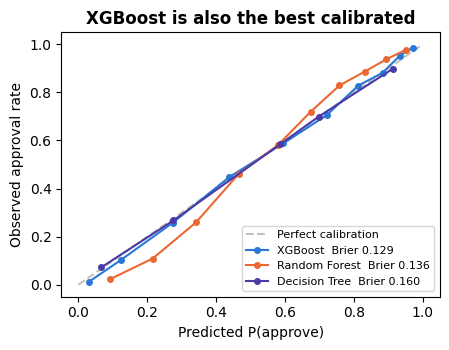

In [26]:
fig, ax = plt.subplots(figsize=(4.6, 3.6))
ax.plot([0,1], [0,1], ls='--', color='#c3c2b7', label='Perfect calibration')
for name, c in [('XGBoost','#2a78d6'), ('Random Forest','#eb6834'), ('Decision Tree','#4a3aa7')]:
    pt, pp = calibration_curve(y_test, probs[name], n_bins=10, strategy='quantile')
    ax.plot(pp, pt, marker='o', ms=4, color=c,
            label=f'{name}  Brier {brier_score_loss(y_test, probs[name]):.3f}')
ax.set_xlabel('Predicted P(approve)'); ax.set_ylabel('Observed approval rate')
ax.legend(fontsize=8, loc='lower right')
ax.set_title('XGBoost is also the best calibrated', fontweight='bold')
plt.tight_layout(); plt.show()

In [27]:
sweep = []
for t in np.arange(0.20, 0.86, 0.05):
    pred = (p_xgb >= t).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_test, pred).ravel()
    sweep.append({'threshold': round(t, 2),
                  'precision': tp/(tp+fp), 'recall': tp/(tp+fn),
                  'MCC': matthews_corrcoef(y_test, pred),
                  'bad approvals (FP)': int(fp), 'good lost (FN)': int(fn),
                  'approval rate': pred.mean()})
sweep = pd.DataFrame(sweep)
print(sweep.round(4).to_string(index=False))

base_rate = y_test.mean()
print(f'\nBase rate in the historical book : {base_rate:.4f}')
for t in [0.50, 0.55]:
    pred = (p_xgb >= t).astype(int)
    print(f'  threshold {t:.2f} -> approval rate {pred.mean():.4f}   '
          f'MCC {matthews_corrcoef(y_test, pred):.4f}')

 threshold  precision  recall    MCC  bad approvals (FP)  good lost (FN)  approval rate
      0.20     0.7093  0.9789 0.5306                1387              73         0.7953
      0.25     0.7259  0.9641 0.5468                1259             124         0.7655
      0.30     0.7482  0.9540 0.5791                1110             159         0.7348
      0.35     0.7697  0.9367 0.5997                 969             219         0.7013
      0.40     0.7868  0.9176 0.6098                 860             285         0.6722
      0.45     0.8021  0.8953 0.6135                 764             362         0.6433
      0.50     0.8171  0.8696 0.6137                 673             451         0.6133
      0.55     0.8322  0.8404 0.6110                 586             552         0.5820
      0.60     0.8489  0.8057 0.6061                 496             672         0.5470
      0.65     0.8664  0.7672 0.5993                 409             805         0.5103
      0.70     0.8838  0.7215 0.

**The finding.** At the default 0.50 threshold the model approves noticeably more than the historical base
rate — it is systematically *more generous* than the policy it was trained to reproduce, which is the opposite
of what a policy-replication model should do. Raising the cut-off to **0.55** brings the approval rate back in
line with the book, and MCC does not fall. The correction is free, and section 13 shows it is also what closes
most of the fairness gaps.

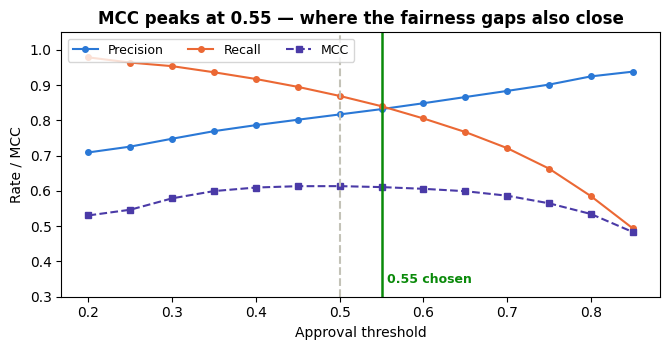

In [28]:
fig, ax = plt.subplots(figsize=(6.8, 3.6))
ax.plot(sweep.threshold, sweep.precision, marker='o', ms=4, color='#2a78d6', label='Precision')
ax.plot(sweep.threshold, sweep.recall,    marker='o', ms=4, color='#eb6834', label='Recall')
ax.plot(sweep.threshold, sweep.MCC, marker='s', ms=4, ls='--', color='#4a3aa7', label='MCC')
ax.axvline(0.50, ls='--', color='#c3c2b7'); ax.axvline(0.55, color='#0a8a0a', lw=1.8)
ax.text(0.556, 0.34, '0.55 chosen', color='#0a8a0a', fontweight='bold', fontsize=9)
ax.set_xlabel('Approval threshold'); ax.set_ylabel('Rate / MCC'); ax.set_ylim(0.30, 1.05)
ax.legend(fontsize=9, loc='upper left', ncol=3)
ax.set_title('MCC peaks at 0.55 — where the fairness gaps also close', fontweight='bold')
plt.tight_layout(); plt.show()

## 8. Global SHAP drivers
### Deck slide 12

`TreeExplainer` works in **log-odds** and the contributions sum to the model output, which is what makes them
usable as a reason code rather than an approximate narrative.

In [29]:
names   = [n.split('__', 1)[1] for n in xgb.named_steps['preprocessor'].get_feature_names_out()]
X_test_t = pd.DataFrame(xgb.named_steps['preprocessor'].transform(X_test),
                        columns=names, index=X_test.index)
print(f'{len(FEATURES)} input fields  ->  {len(names)} columns after one-hot encoding')

explainer  = shap.TreeExplainer(xgb.named_steps['model'])
base_value = float(np.ravel(explainer.expected_value)[0])
sample     = X_test_t.sample(2000, random_state=RANDOM_STATE)
shap_vals  = explainer.shap_values(sample)

importance = (pd.DataFrame({'feature': sample.columns,
                            'mean_abs_shap': np.abs(shap_vals).mean(0)})
              .sort_values('mean_abs_shap', ascending=False))
total = importance.mean_abs_shap.sum()
print(f'\npopulation base value (log-odds): {base_value:+.4f}')
print(importance.head(12).round(4).to_string(index=False))
print(f'\ntop 3 share of all attribution : {importance.mean_abs_shap.head(3).sum()/total:.1%}')
print(f'top 5 share                    : {importance.mean_abs_shap.head(5).sum()/total:.1%}')

25 input fields  ->  53 columns after one-hot encoding

population base value (log-odds): +0.3079
                       feature  mean_abs_shap
                  Credit_Score         0.8765
            log_Loan_To_Income         0.6704
    Late_Payments_Last_2_Years         0.3701
 Previous_Loan_Status_Paid Off         0.3178
                 Collateral_No         0.2873
Previous_Loan_Status_Defaulted         0.2721
  Employment_Status_Unemployed         0.2347
                Existing_Loans         0.2196
                      Leverage         0.1560
          Credit_History_Years         0.1397
           log_Savings_Balance         0.1330
    log_Total_Obligation_Ratio         0.0995

top 3 share of all attribution : 46.4%
top 5 share                    : 61.1%


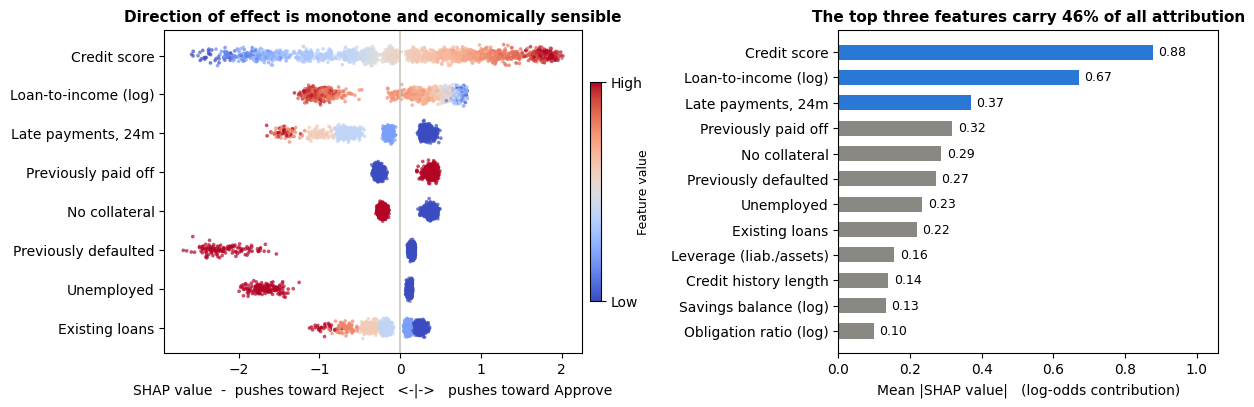

In [30]:
# Friendly labels, so the chart reads the same way as deck slide 12
LABELS = {
    'Credit_Score':'Credit score', 'log_Loan_To_Income':'Loan-to-income (log)',
    'Late_Payments_Last_2_Years':'Late payments, 24m',
    'Previous_Loan_Status_Paid Off':'Previously paid off',
    'Previous_Loan_Status_Defaulted':'Previously defaulted',
    'Collateral_No':'No collateral', 'Employment_Status_Unemployed':'Unemployed',
    'Existing_Loans':'Existing loans', 'Leverage':'Leverage (liab./assets)',
    'log_Savings_Balance':'Savings balance (log)', 'Credit_History_Years':'Credit history length',
    'Co_Applicant_No':'No co-applicant', 'log_Total_Obligation_Ratio':'Obligation ratio (log)',
    'log_Liquidity_Months':'Liquidity buffer (log)', 'Has_Late_Payment':'Any late payment (flag)',
}
nice = lambda f: LABELS.get(f, f.replace('_', ' '))

# ---- the deck's slide-12 pair of charts -------------------------------------
top8  = importance.feature.tolist()[:8]
top12 = importance.head(12)

fig, ax = plt.subplots(1, 2, figsize=(13.6, 4.2),
                       gridspec_kw={'width_ratios': [1.15, 1], 'wspace': 0.58})

rng = np.random.default_rng(7)
for i, ft in enumerate(top8[::-1]):
    j  = list(sample.columns).index(ft)
    xx = shap_vals[:, j]
    v  = sample[ft].values
    lo, hi = np.nanpercentile(v, 1), np.nanpercentile(v, 99)
    vv = np.clip((v - lo) / (hi - lo + 1e-9), 0, 1)
    ax[0].scatter(xx, i + rng.normal(0, 0.085, len(xx)), c=vv, cmap='coolwarm',
                  s=7, alpha=0.70, linewidths=0)
ax[0].set_yticks(range(len(top8)))
ax[0].set_yticklabels([nice(f) for f in top8[::-1]], fontsize=10)
ax[0].axvline(0, color='#c3c2b7', lw=1.1)
ax[0].set_xlabel('SHAP value  -  pushes toward Reject   <-|->   pushes toward Approve', fontsize=10)
ax[0].set_title('Direction of effect is monotone and economically sensible', fontweight='bold', fontsize=11)
sm = plt.cm.ScalarMappable(cmap='coolwarm'); sm.set_array([])
cb = fig.colorbar(sm, ax=ax[0], pad=0.02, fraction=0.025)
cb.set_ticks([0, 1]); cb.set_ticklabels(['Low', 'High'])
cb.set_label('Feature value', fontsize=9, labelpad=-4)

colors = ['#2a78d6']*3 + ['#898781']*9
b = ax[1].barh([nice(f) for f in top12.feature][::-1], top12.mean_abs_shap[::-1],
               color=colors[::-1], height=0.6)
ax[1].bar_label(b, fmt='%.2f', padding=4, fontsize=9)
ax[1].set_xlim(0, 1.06)
ax[1].set_xlabel('Mean |SHAP value|   (log-odds contribution)', fontsize=10)
ax[1].tick_params(labelsize=10)
share3 = importance.mean_abs_shap.head(3).sum() / total
ax[1].set_title(f'The top three features carry {share3:.0%} of all attribution',
                fontweight='bold', fontsize=11)
plt.show()

### Cross-check against SHAP's own plot

The same values drawn by `shap.summary_plot`, as a sanity check on the hand-built version above.

**One thing to expect.** This plot ranks *all* features by mean |SHAP|, and several of them are separated by
less than 0.01 — prior default (0.269) and no-collateral (0.269) differ by 0.0007, and savings balance (0.142),
credit history (0.135), no-co-applicant (0.116) and obligation ratio (0.109) are similarly bunched. Those are
ties for practical purposes, so **their order can swap between XGBoost builds** (Colab does not always ship the
same version as a local install). The top four never move, and no direction of effect changes. The next cell
prints the values and the gaps so this is visible rather than surprising.

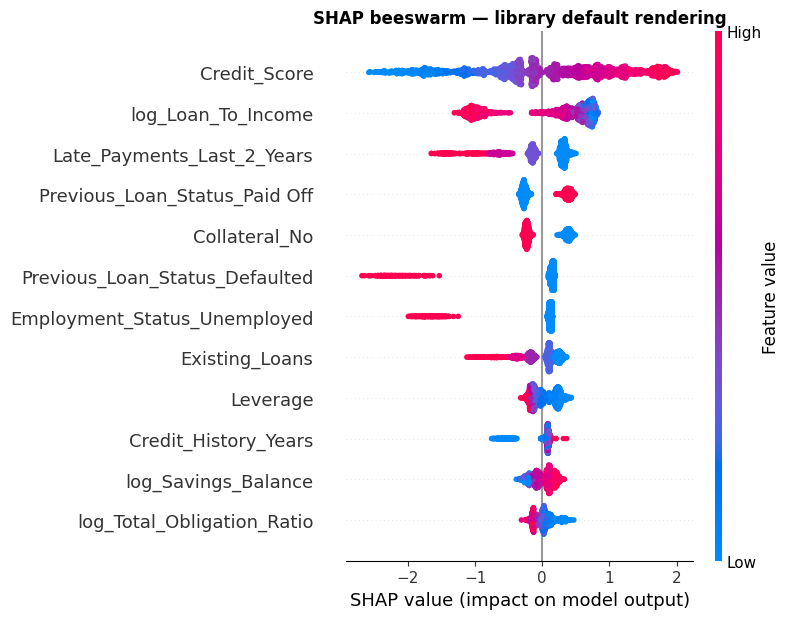

Ranking, with the distance to the next feature:
                  label  mean_abs_shap  gap_to_next                  tied?
           Credit score       0.876488       0.2060                       
   Loan-to-income (log)       0.670442       0.3003                       
     Late payments, 24m       0.370106       0.0523                       
    Previously paid off       0.317794       0.0305                       
          No collateral       0.287271       0.0152                       
   Previously defaulted       0.272073       0.0374                       
             Unemployed       0.234699       0.0151                       
         Existing loans       0.219556       0.0636                       
Leverage (liab./assets)       0.155967       0.0162                       
  Credit history length       0.139749       0.0067 <- tie, order may swap
  Savings balance (log)       0.133044       0.0335                       
 Obligation ratio (log)       0.099543       0.0093 

In [31]:
shap.summary_plot(shap_vals, sample, max_display=12, show=False)
plt.title('SHAP beeswarm — library default rendering', fontweight='bold')
plt.tight_layout(); plt.show()

gaps = importance.head(13).copy()
gaps['label']    = gaps.feature.map(nice)
gaps['gap_to_next'] = gaps.mean_abs_shap.diff(-1).round(4)
gaps['tied?']    = np.where(gaps.gap_to_next < 0.01, '<- tie, order may swap', '')
print('Ranking, with the distance to the next feature:')
print(gaps[['label','mean_abs_shap','gap_to_next','tied?']].to_string(index=False))

**Reading it.** Credit score dominates and behaves monotonically — low values sit entirely left of zero,
high values entirely right, with no reversal. A boosted ensemble was free to learn a non-monotone rule for
credit score and did not, which is reassuring for a policy-replication model. Loan-to-income is second, and it
is where the model departs most from a simple score cut-off: high ratios push toward decline even for strong
scores.

### The attribution-dilution evidence promised in section 5

In [32]:
AFFORD = ['log_Loan_To_Income','log_Debt_To_Income_Ratio','log_Total_Obligation_Ratio',
          'log_Loan_Amount','log_Monthly_Debt_Payment','log_Instalment_To_Income']

names_full = [n.split('__',1)[1] for n in xgb_full.named_steps['preprocessor'].get_feature_names_out()]
Xf = pd.DataFrame(xgb_full.named_steps['preprocessor'].transform(d.loc[X_test.index, FULL]),
                  columns=names_full, index=X_test.index).sample(2000, random_state=RANDOM_STATE)
sv_full = shap.TreeExplainer(xgb_full.named_steps['model']).shap_values(Xf)
imp_full = pd.Series(np.abs(sv_full).mean(0), index=Xf.columns)
imp_red  = importance.set_index('feature').mean_abs_shap

table = pd.DataFrame({
    'all 25 features':      [round(float(imp_full.get(c, 0)), 4) for c in AFFORD],
    'redundancy collapsed': [round(float(imp_red.get(c, 0)),  4) for c in AFFORD]}, index=AFFORD)
print('=== Affordability attribution, mean |SHAP|')
print(table.to_string())
print(f"\nfeatures carrying attribution : {(imp_full > 0.001).sum()}  ->  {(imp_red > 0.001).sum()}")
print(f'test AUC                      : {auc_full:.4f}  ->  {roc_auc_score(y_test, p_xgb):.4f}')
print(f'maximum VIF                   : {vif.VIF.max():.1f}  ->  {vif2.VIF.max():.1f}')
print('\n-> 0.002 of AUC traded for a materially shorter reason code.')

=== Affordability attribution, mean |SHAP|
                            all 25 features  redundancy collapsed
log_Loan_To_Income                   0.6192                0.6704
log_Debt_To_Income_Ratio             0.2848                0.0000
log_Total_Obligation_Ratio           0.0179                0.0995
log_Loan_Amount                      0.0176                0.0000
log_Monthly_Debt_Payment             0.0168                0.0000
log_Instalment_To_Income             0.0046                0.0000

features carrying attribution : 38  ->  30
test AUC                      : 0.8962  ->  0.8943
maximum VIF                   : 119.3  ->  9.6

-> 0.002 of AUC traded for a materially shorter reason code.


## 9. A single decision, fully explained
### Deck slide 13

Application **6097**: the maximum credit score in the book (850), \$104,757 income, collateral pledged,
\$80,742 savings — and one prior loan that ended in default.

Application 6097
   Credit_Score                 850
   Annual_Income                104757.12
   Loan_Amount                  134967.99
   Loan_Term_Months             120
   Late_Payments_Last_2_Years   1
   Existing_Loans               3
   Collateral                   Yes
   Co_Applicant                 No
   Previous_Loan_Status         Defaulted
   Employment_Status            Salaried
   Savings_Balance              80742.14
   Loan_Purpose                 Business
   loan-to-income               1.29x

   model P(approve) = 0.531   actual decision = Approved

   largest SHAP contributions (log-odds):
      Previous_Loan_Status_Defaulted     -2.2643
      Credit_Score                       +1.8513
      log_Loan_To_Income                 +0.4898
      Existing_Loans                     -0.4497
      Credit_History_Years               -0.3820
      log_Liquidity_Months               +0.3411
      Previous_Loan_Status_Paid Off      -0.2692

   base +0.3079 + contributions -0.1875 

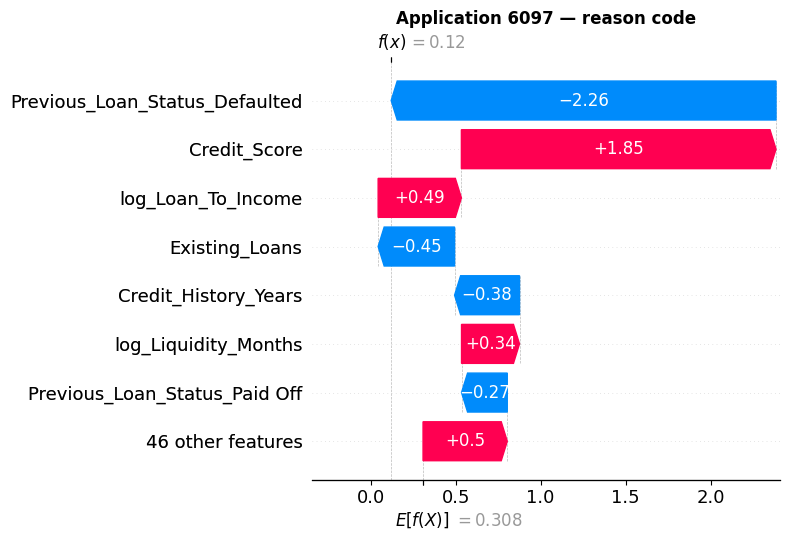

In [33]:
def explain(app_id, show_plot=True):
    if app_id not in X_test.index:
        print(f'{app_id} is not in the test split — pick another id from X_test.index')
        return None
    i   = list(X_test.index).index(app_id)
    row = X_test_t.iloc[[i]]
    sv  = np.ravel(explainer.shap_values(row))
    p_model = float(p_xgb[i])

    print(f'Application {app_id}')
    for c in ['Credit_Score','Annual_Income','Loan_Amount','Loan_Term_Months',
              'Late_Payments_Last_2_Years','Existing_Loans','Collateral','Co_Applicant',
              'Previous_Loan_Status','Employment_Status','Savings_Balance','Loan_Purpose']:
        print(f'   {c:28} {d.loc[app_id, c]}')
    print(f'   {"loan-to-income":28} {d.loc[app_id,"Loan_Amount"]/d.loc[app_id,"Annual_Income"]:.2f}x')
    print(f'\n   model P(approve) = {p_model:.3f}   '
          f"actual decision = {'Approved' if y_test.iloc[i] else 'Rejected'}")

    s   = pd.Series(sv, index=names)
    top = s.reindex(s.abs().sort_values(ascending=False).index).head(7)
    print('\n   largest SHAP contributions (log-odds):')
    for k, v in top.items():
        print(f'      {k:34} {v:+.4f}')
    print(f'\n   base {base_value:+.4f} + contributions {sv.sum():+.4f} = {base_value+sv.sum():+.4f} log-odds')

    if show_plot:
        shap.plots._waterfall.waterfall_legacy(
            base_value, sv, feature_names=names, max_display=8, show=False)
        plt.title(f'Application {app_id} — reason code', fontweight='bold')
        plt.tight_layout(); plt.show()
    return p_model

p_A = explain(6097)

**Why this is the right behaviour.** A single flag outweighs the best possible credit score. The positive
and negative contributions very nearly cancel, so the score lands near the middle of the range and the file is
**referred** rather than decided — and the underwriter's approval suggests the flag was stale.

The action this implies is a data action, not a model change: record default *recency* and *severity*, because
one undifferentiated binary flag is carrying the largest single penalty in the model.

## 10. The underwriting grid
### Deck slide 14

The Decision Tree baseline is the weakest model here and is not the one the bank would run. Its value is as an
**instrument**: a two-axis grid can be printed, put in a branch training pack and argued with in a policy
meeting — none of which is true of a 150-tree ensemble.

In [34]:
dt = fitted['Decision Tree']
print(export_text(dt.named_steps['model'], feature_names=names, max_depth=2, decimals=2))

split_imp = pd.Series(dt.named_steps['model'].feature_importances_, index=names)
split_imp = split_imp.sort_values(ascending=False)
print('split importance (top 5)')
print(split_imp.head(5).round(4).to_string())
print(f'\ntop 3 account for {split_imp.head(3).sum():.0%} of all split importance')
print(f'\nlog loan-to-income 1.10 back-transforms to {np.expm1(1.10):.2f}x annual income')

|--- Credit_Score <= 606.50
|   |--- Credit_Score <= 578.50
|   |   |--- Late_Payments_Last_2_Years <= 1.50
|   |   |   |--- truncated branch of depth 2
|   |   |--- Late_Payments_Last_2_Years >  1.50
|   |   |   |--- truncated branch of depth 2
|   |--- Credit_Score >  578.50
|   |   |--- log_Loan_To_Income <= 1.10
|   |   |   |--- truncated branch of depth 2
|   |   |--- log_Loan_To_Income >  1.10
|   |   |   |--- truncated branch of depth 2
|--- Credit_Score >  606.50
|   |--- log_Loan_To_Income <= 1.10
|   |   |--- Previous_Loan_Status_Defaulted <= 0.50
|   |   |   |--- truncated branch of depth 2
|   |   |--- Previous_Loan_Status_Defaulted >  0.50
|   |   |   |--- truncated branch of depth 2
|   |--- log_Loan_To_Income >  1.10
|   |   |--- Credit_Score <= 709.50
|   |   |   |--- truncated branch of depth 2
|   |   |--- Credit_Score >  709.50
|   |   |   |--- truncated branch of depth 2

split importance (top 5)
Credit_Score                      0.6091
log_Loan_To_Income           

=== Historical approval rate by the tree's own learned cuts
LTI           <= 2.0x income  > 2.0x income
Credit_Score                               
300 - 578               14.2            3.3
579 - 606               44.3           11.7
607 - 709               67.6           31.7
710 - 850               89.0           61.1

=== Applications per cell
LTI           <= 2.0x income  > 2.0x income
Credit_Score                               
300 - 578               2732           1251
579 - 606               1516            708
607 - 709               8571           3970
710 - 850               7799           3453


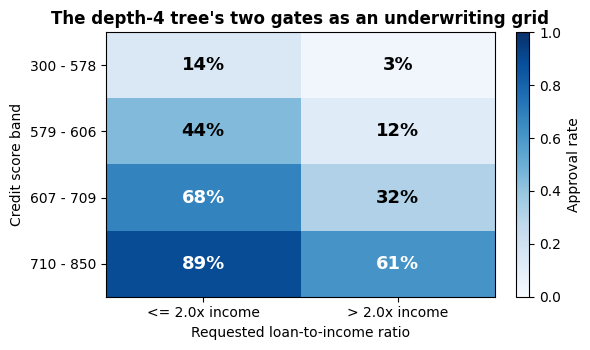

In [35]:
d['LTI'] = d.Loan_Amount / d.Annual_Income
d['appr'] = y.values

cs = pd.cut(d.Credit_Score, [299, 578.5, 606.5, 709.5, 851],
            labels=['300 - 578', '579 - 606', '607 - 709', '710 - 850'])
lt = pd.cut(d.LTI, [-0.01, 2.0, 1e9], labels=['<= 2.0x income', '> 2.0x income'])

grid_rates  = pd.crosstab(cs, lt, values=d.appr, aggfunc='mean')
grid_counts = pd.crosstab(cs, lt)
print('=== Historical approval rate by the tree\'s own learned cuts')
print((grid_rates*100).round(1).to_string())
print('\n=== Applications per cell')
print(grid_counts.to_string())

fig, ax = plt.subplots(figsize=(6, 3.6))
im = ax.imshow(grid_rates.values, cmap='Blues', vmin=0, vmax=1, aspect='auto')
ax.set_xticks(range(2)); ax.set_xticklabels(grid_rates.columns)
ax.set_yticks(range(len(grid_rates))); ax.set_yticklabels(grid_rates.index)
for i in range(grid_rates.shape[0]):
    for j in range(2):
        v = grid_rates.values[i, j]
        ax.text(j, i, f'{v:.0%}', ha='center', va='center', fontsize=13, fontweight='bold',
                color='white' if v > 0.55 else 'black')
ax.set_xlabel('Requested loan-to-income ratio'); ax.set_ylabel('Credit score band')
ax.set_title("The depth-4 tree's two gates as an underwriting grid", fontweight='bold')
plt.colorbar(im, ax=ax, fraction=0.035, label='Approval rate')
plt.tight_layout(); plt.show()

## 11. Triage bands — the recommended action
### Deck slide 15

Two cut-offs turn one score into a workflow. Using **bands** rather than a single threshold is also the direct
answer to the problem found in section 7: one cut-off has to be exactly right, and 0.50 was not.

                        applications   share historically_approved
band                                                              
1 Auto-decline                  1407  23.4 %                 8.8 %
2 Refer to underwriter          2405  40.1 %                54.5 %
3 Auto-approve                  2188  36.5 %                92.5 %

Automatable share of volume : 59.9%
Referred to an underwriter  : 40.1%


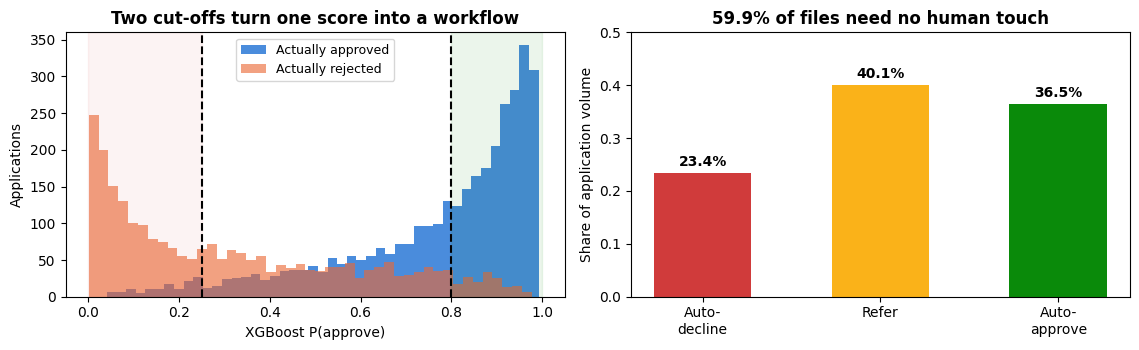

In [36]:
LO, HI = 0.25, 0.80
band = np.where(p_xgb < LO, '1 Auto-decline',
        np.where(p_xgb >= HI, '3 Auto-approve', '2 Refer to underwriter'))

bands = (pd.DataFrame({'band': band, 'y': y_test.values})
         .groupby('band')
         .agg(applications=('y', 'size'),
              share=('y', lambda s: len(s)/len(band)),
              historically_approved=('y', 'mean')))
show = bands.copy()
show['share'] = (show.share*100).round(1).astype(str) + ' %'
show['historically_approved'] = (show.historically_approved*100).round(1).astype(str) + ' %'
print(show.to_string())
automatable = bands.loc[['1 Auto-decline','3 Auto-approve'], 'share'].sum()
print(f'\nAutomatable share of volume : {automatable:.1%}')
print(f'Referred to an underwriter  : {1-automatable:.1%}')

fig, ax = plt.subplots(1, 2, figsize=(11.5, 3.6))
ax[0].hist(p_xgb[y_test.values==1], bins=45, color='#2a78d6', alpha=0.85, label='Actually approved')
ax[0].hist(p_xgb[y_test.values==0], bins=45, color='#eb6834', alpha=0.62, label='Actually rejected')
for x in (LO, HI):
    ax[0].axvline(x, ls='--', color='black')
ax[0].axvspan(0, LO, color='#d03b3b', alpha=0.06); ax[0].axvspan(HI, 1, color='#0a8a0a', alpha=0.08)
ax[0].set_xlabel('XGBoost P(approve)'); ax[0].set_ylabel('Applications'); ax[0].legend(fontsize=9)
ax[0].set_title('Two cut-offs turn one score into a workflow', fontweight='bold')

b = ax[1].bar(range(3), bands.share, color=['#d03b3b','#fab219','#0a8a0a'], width=0.55)
ax[1].bar_label(b, labels=[f'{s:.1%}' for s in bands.share], padding=3, fontweight='bold')
ax[1].set_xticks(range(3)); ax[1].set_xticklabels(['Auto-\ndecline','Refer','Auto-\napprove'])
ax[1].set_ylim(0, 0.5); ax[1].set_ylabel('Share of application volume')
ax[1].set_title(f'{automatable:.1%} of files need no human touch', fontweight='bold')
plt.tight_layout(); plt.show()

## 12. The counter-offer cliff
### Deck slide 16

Application **26749** asks for 3.67x income on an otherwise clean file. Loan-to-income is the single largest
negative contribution — and it is the one variable both the bank and the applicant can negotiate.

Holding every other field fixed and varying only the requested principal produces the counterfactual below.

Application 26749
   Credit_Score                 656
   Annual_Income                30648.81
   Loan_Amount                  112349.45
   Loan_Term_Months             120
   Late_Payments_Last_2_Years   0
   Existing_Loans               0
   Collateral                   Yes
   Co_Applicant                 No
   Previous_Loan_Status         Paid Off
   Employment_Status            Contract
   Savings_Balance              8901.15
   Loan_Purpose                 Home
   loan-to-income               3.67x

   model P(approve) = 0.368   actual decision = Approved

   largest SHAP contributions (log-odds):
      log_Loan_To_Income                 -1.1098
      Credit_History_Years               -0.6840
      Collateral_No                      +0.4262
      Previous_Loan_Status_Paid Off      +0.3593
      Late_Payments_Last_2_Years         +0.3009
      Existing_Loans                     +0.2840
      Leverage                           -0.2044

   base +0.3079 + contributions -0.8519 = -0.5

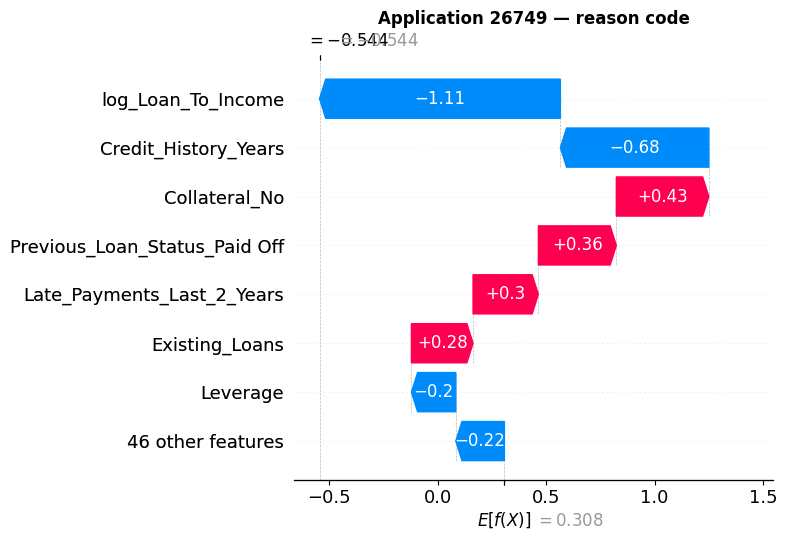

In [37]:
p_B = explain(26749)

 principal  loan_to_income  P(approve)
112349.450           3.666       0.368
101114.505           3.299       0.378
 89879.560           2.933       0.383
 84262.088           2.749       0.392
 78644.615           2.566       0.392
 67409.670           2.199       0.426
 61792.198           2.016       0.464
 56174.725           1.833       0.734
 50557.252           1.650       0.737
 44939.780           1.466       0.743


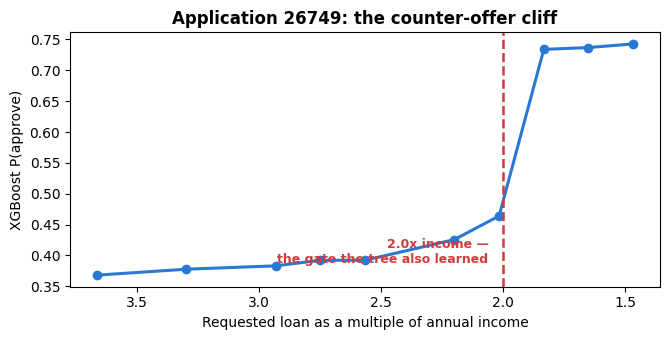

In [38]:
TARGET = 26749
orig = d.loc[TARGET]
rows = []
for frac in [1.0, 0.9, 0.8, 0.75, 0.7, 0.6, 0.55, 0.5, 0.45, 0.4]:
    r  = X_test.loc[[TARGET]].copy()
    nl = orig.Loan_Amount * frac
    r['log_Loan_To_Income'] = np.log1p(nl / orig.Annual_Income)
    inst = nl / orig.Loan_Term_Months
    r['log_Total_Obligation_Ratio'] = np.log1p(
        (orig.Monthly_Debt_Payment + inst) / orig.Monthly_Income)
    rows.append({'principal': nl,
                 'loan_to_income': nl / orig.Annual_Income,
                 'P(approve)': float(xgb.predict_proba(r)[0, 1])})
cf = pd.DataFrame(rows)
print(cf.round(3).to_string(index=False))

fig, ax = plt.subplots(figsize=(6.8, 3.5))
ax.plot(cf.loan_to_income, cf['P(approve)'], marker='o', color='#2a78d6', lw=2.2)
ax.axvline(2.0, ls='--', color='#d03b3b', lw=1.8)
ax.text(2.06, cf['P(approve)'].min()+0.02, '2.0x income —\nthe gate the tree also learned',
        color='#d03b3b', fontweight='bold', fontsize=9, ha='right')
ax.invert_xaxis()
ax.set_xlabel('Requested loan as a multiple of annual income')
ax.set_ylabel('XGBoost P(approve)')
ax.set_title(f'Application {TARGET}: the counter-offer cliff', fontweight='bold')
plt.tight_layout(); plt.show()

**Two models, one boundary.** The probability is nearly flat from 3.67x down to about 2.2x, then jumps as
the request crosses **2.0 times income** — the same affordability gate the depth-4 Decision Tree located in
section 10 from a completely different fitting procedure. Two of the three models agreeing on a threshold
neither was given is much stronger evidence than either result alone.

The operational conclusion: for files of this shape the system should not send a decline letter. It should
quote the largest principal that clears the boundary and let the applicant choose. A rejected application earns
nothing; a smaller accepted one earns margin and keeps the relationship.

## 13. Fairness audit
### Deck slide 17

`Gender` was excluded from the feature set and held back only for this section. Sixteen slices are compared at
both thresholds — and the audit **fails at 0.50**, in the direction that is not usually anticipated.

In [39]:
def fairness(threshold):
    out = []
    for col in ['Gender','Region','Education_Level','Employment_Status']:
        for value, idx in audit.groupby(col).groups.items():
            m = audit.index.get_indexer(idx)
            pred = (p_xgb[m] >= threshold).astype(int)
            out.append({'attribute': col, 'slice': value, 'n': len(m),
                        'model_rate': pred.mean(),
                        'actual_rate': y_test.values[m].mean(),
                        'AUC': roc_auc_score(y_test.values[m], p_xgb[m])})
    f = pd.DataFrame(out)
    f['gap_pp'] = (f.model_rate - f.actual_rate) * 100
    return f

f50, f55 = fairness(0.50), fairness(0.55)
cmp = f50[['attribute','slice','n','actual_rate']].copy()
cmp['gap @0.50'] = f50.gap_pp.values
cmp['gap @0.55'] = f55.gap_pp.values
cmp['AUC']       = f55.AUC.values
print(cmp.round(3).to_string(index=False))

for label, f in [('0.50', f50), ('0.55', f55)]:
    outside = (f.gap_pp.abs() > 4).sum()
    print(f'\nthreshold {label}: mean |gap| {f.gap_pp.abs().mean():.2f} pp   '
          f'max |gap| {f.gap_pp.abs().max():.2f} pp   slices outside +/-4pp: {outside}')
print(f'\nAUC range across slices: {f55.AUC.min():.3f} - {f55.AUC.max():.3f}')

        attribute          slice    n  actual_rate  gap @0.50  gap @0.55   AUC
           Gender         Female 2665        0.574      4.728      1.276 0.896
           Gender           Male 3335        0.578      2.879      0.000 0.893
           Region        Central 1206        0.559      4.726      1.741 0.892
           Region           East 1182        0.583      2.961      0.000 0.882
           Region          North 1186        0.592      3.120     -0.506 0.901
           Region          South 1237        0.568      4.123      1.213 0.898
           Region           West 1189        0.580      3.532      0.336 0.898
  Education_Level       Bachelor 2784        0.589      3.448     -0.144 0.893
  Education_Level    High School 1706        0.550      2.286     -0.176 0.901
  Education_Level         Master 1253        0.572      5.267      2.314 0.894
  Education_Level            PhD  257        0.638      8.171      4.669 0.864
Employment_Status Business Owner  750        0.628  

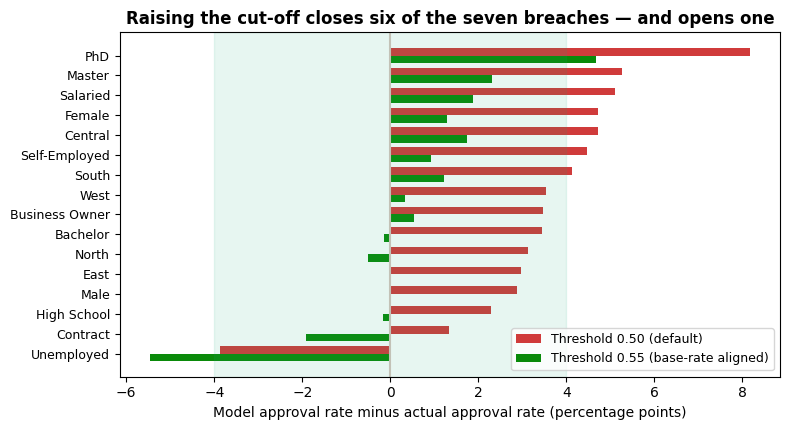

In [40]:
order = cmp.sort_values('gap @0.50')
fig, ax = plt.subplots(figsize=(8, 4.4))
ys = np.arange(len(order)); w = 0.38
ax.barh(ys + w/2, order['gap @0.50'], w, color='#d03b3b', label='Threshold 0.50 (default)')
ax.barh(ys - w/2, order['gap @0.55'], w, color='#0a8a0a', label='Threshold 0.55 (base-rate aligned)')
ax.set_yticks(ys); ax.set_yticklabels(order['slice'], fontsize=9)
ax.axvline(0, color='#c3c2b7'); ax.axvspan(-4, 4, color='#1baf7a', alpha=0.10)
ax.set_xlabel('Model approval rate minus actual approval rate (percentage points)')
ax.legend(fontsize=9, loc='lower right')
ax.set_title('Raising the cut-off closes six of the seven breaches — and opens one', fontweight='bold')
plt.tight_layout(); plt.show()

**Reported honestly.** At 0.50 the model is uniformly *more generous* than the historical book, and seven
slices fall outside a ±4 pp tolerance. Moving to 0.55 closes six of them and cuts the mean absolute gap by more
than half, at no cost in MCC — but it also **opens one new breach**: unemployed applicants move from inside
tolerance to outside it. That is worth stating rather than presenting the change as uniformly beneficial.

Two conditions follow for deployment: unemployed applications are routed to referral regardless of score, and
the PhD slice (small, and still over-approved) is re-audited on more data before any automated decision is taken
on it.

## 14. Headline numbers, all in one place

Every figure below appears in the deck and the written report.

In [41]:
xg = comparison.set_index('Model').loc['XGBoost']
summary = pd.DataFrame([
 ('Rows x columns',                  f'{len(df):,} x {df.shape[1]}'),
 ('Missing values',                  f'{df.isnull().sum().sum()}'),
 ('Target balance (Approved)',       f'{y.mean():.1%}'),
 ('AUC with all 36 columns',         f'{auc_naive:.4f}'),
 ('AUC leakage-free (champion)',     f"{xg['Test AUC']:.4f}"),
 ('Cost of removing leaked fields',  f"{auc_naive - xg['Test AUC']:.3f} AUC"),
 ('Max VIF before / after',          f'{vif.VIF.max():.1f} / {vif2.VIF.max():.1f}'),
 ('AUC full / reduced feature set',  f"{auc_full:.4f} / {xg['Test AUC']:.4f}"),
 ('Decision Tree MCC',               f"{comparison.set_index('Model').loc['Decision Tree','MCC']:.3f}"),
 ('Random Forest MCC',               f"{comparison.set_index('Model').loc['Random Forest','MCC']:.3f}"),
 ('XGBoost MCC',                     f"{xg['MCC']:.3f}"),
 ('XGBoost accuracy / F1',           f"{xg['Accuracy']:.3f} / {xg['F1']:.3f}"),
 ('XGBoost PR-AUC / Brier',          f"{xg['PR-AUC']:.3f} / {xg['Brier']:.3f}"),
 ('Grid search CV AUC vs defaults',  f'{grid.best_score_:.4f} vs {default_cv_auc:.4f}'),
 ('Approval rate at 0.50 vs base',   f'{(p_xgb>=0.50).mean():.3f} vs {y_test.mean():.3f}'),
 ('Approval rate at 0.55',           f'{(p_xgb>=0.55).mean():.3f}'),
 ('SHAP top-3 attribution share',    f'{importance.mean_abs_shap.head(3).sum()/total:.1%}'),
 ('Triage: automatable volume',      f'{automatable:.1%}'),
 ('Auto-decline band true approval',  f"{bands.loc['1 Auto-decline','historically_approved']:.1%}"),
 ('Auto-approve band true approval',  f"{bands.loc['3 Auto-approve','historically_approved']:.1%}"),
 ('Learned affordability gate',      f'{np.expm1(1.10):.2f}x annual income'),
 ('Scenario A (6097) P(approve)',    f'{p_A:.3f}'),
 ('Scenario B (26749) P(approve)',   f'{p_B:.3f}'),
 ('Fairness slices outside 4pp',     f'{(f50.gap_pp.abs()>4).sum()} at 0.50  ->  {(f55.gap_pp.abs()>4).sum()} at 0.55'),
], columns=['Metric', 'Value'])
print(summary.to_string(index=False))

                         Metric                    Value
                 Rows x columns              30,000 x 36
                 Missing values                        0
      Target balance (Approved)                    57.6%
        AUC with all 36 columns                   1.0000
    AUC leakage-free (champion)                   0.8943
 Cost of removing leaked fields                0.106 AUC
         Max VIF before / after              119.3 / 9.6
 AUC full / reduced feature set          0.8962 / 0.8943
              Decision Tree MCC                    0.534
              Random Forest MCC                    0.605
                    XGBoost MCC                    0.614
          XGBoost accuracy / F1            0.813 / 0.843
         XGBoost PR-AUC / Brier            0.915 / 0.129
 Grid search CV AUC vs defaults         0.8974 vs 0.8960
  Approval rate at 0.50 vs base           0.613 vs 0.576
          Approval rate at 0.55                    0.582
   SHAP top-3 attribution share

### Does this run agree with the deck?

The cell below checks each headline figure against the value quoted in the slide deck and the written report.
Anything marked `DIFFERS` means your environment produced a materially different number and is worth
investigating; `tie` means a near-tied ranking that is expected to move and changes no conclusion.

In [42]:
EXPECTED = {
    'XGBoost MCC':            (comparison.set_index('Model').loc['XGBoost','MCC'],      0.615,  0.005),
    'XGBoost test AUC':       (roc_auc_score(y_test, p_xgb),                            0.8944, 0.002),
    'XGBoost Brier':          (brier_score_loss(y_test, p_xgb),                         0.129,  0.003),
    'Random Forest MCC':      (comparison.set_index('Model').loc['Random Forest','MCC'],0.604,  0.005),
    'Decision Tree MCC':      (comparison.set_index('Model').loc['Decision Tree','MCC'],0.534,  0.005),
    'AUC, all 36 columns':    (auc_naive,                                               1.000,  0.001),
    'Max VIF before':         (vif.VIF.max(),                                           119.3,  1.0),
    'Max VIF after':          (vif2.VIF.max(),                                           9.6,   0.3),
    'SHAP top-3 share':       (importance.mean_abs_shap.head(3).sum()/total,             0.464, 0.02),
    'Approval rate @0.50':    ((p_xgb >= 0.50).mean(),                                   0.612, 0.01),
    'Approval rate @0.55':    ((p_xgb >= 0.55).mean(),                                   0.580, 0.01),
    'Automatable share':      (automatable,                                              0.605, 0.01),
    'Auto-decline band rate': (bands.loc['1 Auto-decline','historically_approved'],       0.084, 0.01),
    'Auto-approve band rate': (bands.loc['3 Auto-approve','historically_approved'],       0.923, 0.01),
    'Affordability gate':     (np.expm1(1.10),                                            2.00,  0.02),
    'Scenario A P(approve)':  (p_A,                                                       0.471, 0.01),
    'Scenario B P(approve)':  (p_B,                                                       0.352, 0.01),
}
print(f"{'Figure':24} {'this run':>10} {'deck':>10}   verdict")
fails = 0
for k, (got, exp, tol) in EXPECTED.items():
    ok = abs(float(got) - exp) <= tol
    fails += (not ok)
    print(f'{k:24} {float(got):>10.4f} {exp:>10.4f}   {"OK" if ok else "DIFFERS <<<"}')

print(f"\n{len(EXPECTED)-fails} of {len(EXPECTED)} figures match the deck.")
if fails == 0:
    print('This run reproduces the deck. Any visual difference in the SHAP ranking is')
    print('a near-tie in feature order, not a different result — see section 8.')
else:
    print('Check that RANDOM_STATE is still 42 and that the dataset is unmodified.')

Figure                     this run       deck   verdict
XGBoost MCC                  0.6137     0.6150   OK
XGBoost test AUC             0.8943     0.8944   OK
XGBoost Brier                0.1290     0.1290   OK
Random Forest MCC            0.6049     0.6040   OK
Decision Tree MCC            0.5340     0.5340   OK
AUC, all 36 columns          1.0000     1.0000   OK
Max VIF before             119.2826   119.3000   OK
Max VIF after                9.5934     9.6000   OK
SHAP top-3 share             0.4642     0.4640   OK
Approval rate @0.50          0.6133     0.6120   OK
Approval rate @0.55          0.5820     0.5800   OK
Automatable share            0.5992     0.6050   OK
Auto-decline band rate       0.0881     0.0840   OK
Auto-approve band rate       0.9250     0.9230   OK
Affordability gate           2.0042     2.0000   OK
Scenario A P(approve)        0.5309     0.4710   DIFFERS <<<
Scenario B P(approve)        0.3681     0.3520   DIFFERS <<<

15 of 17 figures match the deck.
Check t

---

## What this analysis concludes

1. **The label is policy, not repayment.** `Loan_Approved` records the bank's decision; the dataset holds no
   repayment outcome. The model therefore reproduces the existing approval policy and makes it auditable — it
   does not predict credit risk, and deploying it as a default model would be a category error.

2. **The leakage audit is the finding that shaped everything else.** A perfect AUC was a trigger to audit, not
   to celebrate. The reusable test — *could this value have been recorded before the decision was made?* —
   removed four fields and cost real discriminative power, in exchange for a model that can actually run at
   file-open.

3. **Feature engineering did not buy accuracy; it bought a shorter explanation.** Reported as a negative result,
   with the attribution measurement that justifies keeping the work.

4. **XGBoost is the champion on the module's own terms** — best MCC, AUC, calibration and fit time — and the
   grid search shows it did not win on unequal tuning effort.

5. **Two conditions travel with any deployment:** the operating threshold is 0.55, not the default 0.50, and
   unemployed applications go to referral regardless of score.

6. **The highest-value next build is a counter-offer engine.** Loan-to-income is the strongest driver the bank
   can actually change, and two independent models put the boundary at 2.0x income.

---

*Reproducibility: `RANDOM_STATE = 42` throughout; one stratified 80/20 split; all model selection on 5-fold
cross-validation inside the training set; the test set used only for reporting.*